<a href="https://colab.research.google.com/github/poonamgonkar0/AI-Utility-App/blob/master/Healthcare_Customer_Support_Router_Agentic_RAG_System_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain==0.3.20

In [2]:
!pip install langchain-openai==0.3.9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 18.4 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.54.0
    Uninstalling openai-2.54.0:
      Successfully uninstalled openai-2.54.0


In [3]:
!pip install langchain-community==0.3.20

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.20
    Uninstalling langchain-0.3.20:
      Successfully uninstalled langchain-0.3.20


In [4]:
!pip install langgraph==0.3.18

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: langgraph-sdk
    Found existing installation: langgraph-sdk 0.4.4
    Uninstalling langgraph-sdk-0.4.4:
      Successfully uninstalled langgraph-sdk-0.4.4
  Attempting uninstall: langgraph-checkpoint
    Found existing installation: langgraph-checkpoint 4.2.0
    Uninstalling langgraph-checkpoint-4.2.0:
      Successfully uninstalled langgraph-checkpoint-4.2.0
  Attempting uninstall: langgraph-prebuilt
    Found existing installation: langgraph-prebuilt 1.1.0
    Uninstalling langgraph-prebuilt-1.1.0:
      Successfully uninstalled langgraph-prebuilt-1.1.0
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.11
    Uninstalling langgraph-1.2.11:
      Successfully uninstalled langgraph-1.2.11


Install ChromaDB LangChain Wrapper for Vector DB

In [1]:
!pip install langchain_chroma

Install Jupyter Widgets for Building Form UI elements

In [6]:
!pip install ipywidgets
!pip install jupyter-ui-poll==1.0.0
# this is used for testimg- no front end needed-  before project goes live u can do here testing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 21.5 MB/s eta 0:00:00


## Api setup and model creation

In [4]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

Enter Open AI API Key: ··········


In [5]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_openai import ChatOpenAI

llm=ChatOpenAI(model='gpt-4o-mini', api_key = OPENAI_KEY)

openai_embed_model = OpenAIEmbeddings(model='text-embedding-3-small')

## Data uploading

In [7]:
!gdown 1_bQj7VkXDMwwqJmspFgRzH2mgK1CVMUY

Downloading...
From: https://drive.google.com/uc?id=1_bQj7VkXDMwwqJmspFgRzH2mgK1CVMUY
To: /content/healthcare_db.json
100% 10.6k/10.6k [00:00<00:00, 19.5MB/s]


In [8]:
import json

with open("./healthcare_db.json", "r") as f:
    knowledge_base = json.load(f)

knowledge_base[:3]

[{'text': "Question: How can I view my healthcare billing statement online? Answer: You can view your billing statement by logging into your patient portal and selecting 'Billing Statements'.",
  'metadata': {'category': 'billing'}},
 {'text': 'Question: What payment methods are accepted for medical bills? Answer: We accept credit cards, bank transfers, and insurance payments for settling your medical bills.',
  'metadata': {'category': 'billing'}},
 {'text': 'Question: Can I get a detailed invoice for my medical services? Answer: Yes, a detailed invoice is available in your patient portal under the billing section.',
  'metadata': {'category': 'billing'}}]

In [9]:
from langchain.docstore.document import Document

processed_docs = []

for doc in knowledge_base :
    metadata = doc['metadata']
    data = doc['text']
    processed_docs.append(Document(page_content=data,
                                   metadata=metadata))

processed_docs[:3]

[Document(metadata={'category': 'billing'}, page_content="Question: How can I view my healthcare billing statement online? Answer: You can view your billing statement by logging into your patient portal and selecting 'Billing Statements'."),
 Document(metadata={'category': 'billing'}, page_content='Question: What payment methods are accepted for medical bills? Answer: We accept credit cards, bank transfers, and insurance payments for settling your medical bills.'),
 Document(metadata={'category': 'billing'}, page_content='Question: Can I get a detailed invoice for my medical services? Answer: Yes, a detailed invoice is available in your patient portal under the billing section.')]

## Create Vector Database

In [10]:
from langchain_chroma import Chroma

kbase_db = Chroma.from_documents(documents=processed_docs,
                                  collection_name='knowledge_base',
                                  embedding=openai_embed_model,
                                  collection_metadata={"hnsw:space": "cosine"},   # need to set the distance function to cosine else it uses euclidean by default
                                  persist_directory="./knowledge_base")

## Create Vector Database Retriever Strategy

In [11]:
kbase_search = kbase_db.as_retriever(search_type="similarity_score_threshold",
                                     search_kwargs={"k": 3, "score_threshold": 0.4})

In [12]:
query = 'what payment methods do you accept?'
metadata_filter = {'category' : 'billing'}
# Update retriever search_kwargs dynamically
kbase_search.search_kwargs["filter"] = metadata_filter
kbase_search.invoke(query)

[Document(id='a10ac9ad-b93e-4a27-bc24-dc5b24bc56c9', metadata={'category': 'billing'}, page_content='Question: What payment methods are accepted for medical bills? Answer: We accept credit cards, bank transfers, and insurance payments for settling your medical bills.')]

In [14]:

# Extract the unique 'category' values from the metadata

results = kbase_db._collection.get(              # Retrieve all metadata from the collection
    include=["metadatas"])

unique_categories = set()
for metadata in results["metadatas"]:
    if "category" in metadata:
        unique_categories.add(metadata["category"])

print(unique_categories)


{'insurance', 'appointments', 'billing', 'medical_records'}


# Build the Router Agentic RAG System

![](https://i.imgur.com/jkQZ17g.png)

![](https://i.imgur.com/OKLpCFE.png)

## Define the Agent State Schema

Here we define the key state schema that maintains the agent's state across different steps of execution in the LangGraph workflow.

We define a `CustomerSupportAgentState` typed dictionary to track relevant information for each customer interaction:
- **customer_query**: The text of the customer's question.
- **query_category**: Categorized as one of `Billing`, `Appointments`, `Records`, or `Insurance`, based on the nature of the query.
- **query_sentiment**: The inferred sentiment of the query, which can be `Positive`, `Neutral`, `Negative`, or `Distress`, used to guide escalation or empathetic handling.
- **escalation_cust_info**: A dictionary containing customer information needed in case the query requires escalation to a human support agent.
- **oncall_cust_info**: A dictionary with on-call agent or customer-specific contact details for real-time support handling.
- **final_response**: The final system-generated response sent back to the customer.

We also define two Pydantic models to enforce valid values for key variables:
- `QueryCategory`: Ensures the query category is one of the expected types.
- `QuerySentiment`: Ensures the sentiment label is one of the predefined options used for prioritization and routing.

## Plan the Agent Workflow Structure

This is the Agent workflow we will be using

![](https://i.imgur.com/1I4VJid.png)

Next up we will define python functions for each of the nodes in this Agent graph

In [15]:
from typing import TypedDict, Literal
from pydantic import BaseModel

class CustomerSupportAgentState(TypedDict):
    customer_query: str
    query_category: str
    query_sentiment: str
    escalation_cust_info: dict
    oncall_cust_info: dict
    final_response: str

class QueryCategory(BaseModel):
    categorized_topic: Literal['Billing', 'Appointments', 'Records', 'Insurance']

class QuerySentiment(BaseModel):
    sentiment: Literal['Positive', 'Neutral', 'Negative', 'Distress']

## Create Node Functions

Each function below represents a stage in processing a customer inquiry in the Intelligent Router Agentic RAG System:

1. **categorize_inquiry**: Uses an LLM to classify the user's query into a department such as billing, appointments, records, or insurance.
2. **analyze_inquiry_sentiment**: Evaluates the sentiment of the user’s query (positive, neutral, negative, or distress) to determine the appropriate handling route.
3. **accept_user_input_escalation**: Collects additional input from the user when a negative sentiment is detected to facilitate escalation to a human support agent.
4. **escalate_to_human_agent**: Escalates the query and submitted form details to a human agent for personalized resolution.
5. **accept_user_input_oncall**: Collects additional input from the user when a distress sentiment is detected for emergency handling.
6. **escalate_to_oncall_team**: Escalates the query and form details to the on-call medical team for urgent resolution.
7. **generate_department_response**: Routes the query to the appropriate department-specific RAG workflow and generates a response using relevant context documents.


In [16]:
#categorize_inquiry
def categorize_inquiry(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:
    """
    Classify the customer query into 'Billing', 'Appointments', 'Records' or 'Insurance'.
    """

    query = support_state["customer_query"]
    ROUTE_CATEGORY_PROMPT = """Act as a customer support agent trying to best categorize the customer query.
                               You are a support agent for a healthcare company focusing on providing healthcare services to customers.
                               These services include:
                                - handling billing queries
                                - handling insurance queries
                                - handling appointment booking queries
                                - handling medical records queries

                               Please read the customer query below and
                               determine the best category from the following list:

                               'Billing', 'Appointments', 'Records' or 'Insurance'

                               Remember:
                                - Billing queries will focus more on payment and billing related aspects
                                - Appointments will focus more on booking, rescheduling, cancelling doctor appointments
                                - Records will focus more on updating, sharing, accessing medical records
                                - Insurance will focus more on insurance related queries like claims, updating insurance policy details

                                Return just the category name (from one of the above)

                                Query:
                                {customer_query}
                            """
    prompt = ROUTE_CATEGORY_PROMPT.format(customer_query=query)
    route_category = llm.with_structured_output(QueryCategory).invoke(prompt)

    return {
        "query_category": route_category.categorized_topic
    }

In [17]:
categorize_inquiry({"customer_query": "how to book an appointment with Doctor?"})

{'query_category': 'Appointments'}

In [19]:
#analyze_inquiry_sentiment
def analyze_inquiry_sentiment(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:
    """
    Analyze the sentiment of the customer query as Positive, Neutral, Negative or Distress.
    """

    query = support_state["customer_query"]
    SENTIMENT_CATEGORY_PROMPT = """Act as a customer support agent trying to best categorize the customer query.
                                   You are a support agent for a healthcare company focusing on providing healthcare services to customers.
                                   These services include:
                                    - handling billing queries
                                    - handling insurance queries
                                    - handling appointment booking queries
                                    - handling medical records queries

                                   Please read the customer query below,
                                   analyze its sentiment which should be one from the following list:

                                   'Positive', 'Neutral', 'Negative' or 'Distress'.

                                   Remember these rules when finding the sentiment:
                                     - 'Distress' happens only when the customer is facing a health emergency and might need the on-call emergency doctor
                                     - 'Negative' happens only when the customer is not happy with certain products, services offered by the company

                                   Return just the sentiment (from one of the above)

                                   Query:
                                   {customer_query}
                                """
    prompt = SENTIMENT_CATEGORY_PROMPT.format(customer_query=query)
    sentiment_category = llm.with_structured_output(QuerySentiment).invoke(prompt)

    return {
        "query_sentiment": sentiment_category.sentiment
    }

In [20]:
analyze_inquiry_sentiment({"customer_query": "I am getting proper services here and am happy now."})

{'query_sentiment': 'Positive'}

### Create the accept_user_input_escalation function

![](https://i.imgur.com/nwTR2ce.png)

Collects additional input from the user when a negative sentiment is detected to facilitate escalation to a human support agent.

This function opens up a simple form using Jupyter widgets as a User Interface (UI), accepts information from the user in the UI and saves it in the agent state to be used later. Example shown below here:

![](https://i.imgur.com/feZqjwj.png)

__Note:__ You are free to implement your own UI based workflows to accept user input when you build or integrate such a system in your existing applications \ organization

In [22]:
#accept_user_input_escalation
import ipywidgets as widgets
from IPython.display import display
from jupyter_ui_poll import ui_events
import time

def accept_user_input_escalation(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:

    global form_submitted  # status variable to track form submission
    form_submitted = False # initially form hasn't been submitted

    # UI Header: A simple HTML element to label the form
    header = widgets.HTML("<h3>Escalation Form - Please enter your details below:</h3>")

    # Text input fields to collect user information
    input1 = widgets.Text(description='Name:')     # User's full name
    input2 = widgets.Text(description='Number:')   # Contact number
    input3 = widgets.Text(description='Email:')    # Email address

    # Dictionary to store form responses after submission
    result = {}

    # Callback function to be triggered when the Submit button is clicked
    def on_submit(submit_button):
        global form_submitted
        form_submitted = True  # Mark the form as submitted
        # Store user inputs into the result dictionary
        result['name'] = input1.value
        result['number'] = input2.value
        result['email'] = input3.value
        # Provide visual feedback that form is submitted
        submit_button.description = '👍'

    # Submit button widget setup
    submit_button = widgets.Button(description="Submit")
    submit_button.on_click(on_submit)  # Attach callback to button

    # Combine all widgets into a vertical layout box
    vbox = widgets.VBox([header, input1, input2, input3, submit_button])
    display(vbox)  # Render the form in the notebook interface

    # Keep polling UI events until the form is submitted
    with ui_events() as poll:
        while form_submitted is False:
            poll(5)               # Listen for UI events
            print('.', end='')   # Show a dot to indicate waiting for input from user
            time.sleep(0.3)      # Slight delay to reduce CPU usage

    # Return updated agent state with captured user info for escalation
    return {
        'escalation_cust_info': result
    }



In [23]:
accept_user_input_escalation({})

...............................................................

{'escalation_cust_info': {'name': 'poonam',
  'number': '9876543210',
  'email': 'sdsa@gmail.com'}}

### Create the escalate_to_human_agent function

Escalates the query and submitted form details to a human agent for personalized resolution.

The agent shows a response back to the user with their form input details that they will be contacted soon.

__Note:__ You are free to implement any custom logic here to:
 - Send emails to human agent
 - Call APIs to notify support agent like Whatsapp or internal company platforms

In [31]:
def escalate_to_human_agent(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:

    # Here we have kept it very simple but We can always customize the way you notify the human support agent by adding custom code below.
    # This could include emailing them, paging them, sending them notifications using specific platform APIs like whatsapp etc as per the requirments.



    # get the customer info from agent state which they entered in the form
    escalation_cust_info = support_state['escalation_cust_info']
    # the following response will be shown to the user and can also be sent (customer form inputs) to your human support agents
    response = ("Apologies, " + escalation_cust_info['name'] +
                ",  we are really sorry! Someone from our team will be reaching out to via email shortly at "+
                escalation_cust_info['email'] + " and if needed we will also be calling you at: " +
                escalation_cust_info['number'] + " to help you out!")

    # NOTE: we can always add custom code here to call specific APIs like whatsapp or email etc to notify your human support agents

    return {
        "final_response": response
    }

### Create the accept_user_input_oncall function

![](https://i.imgur.com/FrKgxox.png)

Collects additional input from the user when a distress sentiment is detected to facilitate escalation to a human doctor from the on-call emergency team.

This function opens up a simple form using Jupyter widgets as a User Interface (UI), accepts information from the user in the UI and saves it in the agent state to be used later. Example shown below here:

![](https://i.imgur.com/RvOWl3u.png)

__Note:__ You are free to implement your own UI based workflows to accept user input when you build or integrate such a system in your existing applications \ organization

In [28]:
def accept_user_input_oncall(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:

    global form_submitted  # status variable to track form submission
    form_submitted = False # initially form hasn't been submitted

    # UI Header: Display a title for the emergency form
    header = widgets.HTML("<h3>Emergency Form - Please enter your details below:</h3>")

    # Text input fields to collect critical user info
    input1 = widgets.Text(description='Name:')     # User's full name
    input2 = widgets.Text(description='Number:')   # Contact number (required for emergency callback)

    # Dictionary to store the captured input values
    result = {}

    # Callback function executed when user clicks the Submit button
    def on_submit(submit_button):
        global form_submitted
        form_submitted = True  # Form is now submitted
        # Save form data to result dictionary
        result['name'] = input1.value
        result['number'] = input2.value
        # Visual confirmation of submission
        submit_button.description = '👍'

    # Submit button widget setup
    submit_button = widgets.Button(description="Submit")
    submit_button.on_click(on_submit)  # Attach the callback function

    # Combine widgets vertically and render in notebook
    vbox = widgets.VBox([header, input1, input2, submit_button])
    display(vbox)

    # Keep polling for UI events until form is submitted
    with ui_events() as poll:
        while form_submitted is False:
            poll(5)               # Monitor UI events
            print('.', end='')   # Show a dot to indicate waiting for input from user
            time.sleep(0.3)      # Slight delay to reduce CPU usage

    # Return updated agent state with emergency form details
    return {
        'oncall_cust_info': result
    }


In [29]:
accept_user_input_oncall({})

......................................

{'oncall_cust_info': {'name': 'Poonam Gonkar', 'number': '9876543210'}}

### Create the escalate_to_oncall_team function

Escalates the query and form details to the on-call medical team for urgent resolution.

The agent shows a response back to the user with their form input details that they will be contacted soon by a doctor from the emergency on-call team.

__Note:__ You are free to implement any custom logic here to:
 - Call APIs to notify doctors from the on-call team using Whatsapp or internal company platform tools

In [30]:
def escalate_to_oncall_team(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:

    #  we just show a response back to the user showing the details they entered in the form earlier
    #  telling them they will be contacted by a doctor from the on-call team

    # get the customer info from agent state which they entered in the form
    oncall_cust_info = support_state['oncall_cust_info']
    # the following response will be shown to the user and can also be sent (customer form inputs) to your on-call doctors
    response = ("Don't worry " + oncall_cust_info['name'] +
               "!, someone from our on-call expert doctors will be reaching out to your shortly at " +
                oncall_cust_info['number'] +
                " for assistance immediately!")

    # NOTE: we can always add custom code here to call specific APIs like whatsapp to notify your on-call doctors

    return {
        "final_response": response
    }

### Create the generate_department_response function

Gets the user query and query department category from the agent state.

Uses Vector DB metadata filtering and retrieval to retrieve top-K documents which are cosine similar to the user query

![](https://i.imgur.com/7DA9H7I.png)

Uses standard RAG by passing these documents and query to an LLM to generate a contextual response and update the `final_response` key in the agent state.

__Note:__ You can maintain separate Vector DBs for each category also and route to the right Vector DB based on the query category

In [32]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Dict

def generate_department_response(support_state: CustomerSupportAgentState) -> CustomerSupportAgentState:
    """
    Provide a department support response by combining knowledge from the vector store and LLM.
    """
    # Retrieve category and ensure it is lowercase for metadata filtering
    categorized_topic = support_state["query_category"]
    query = support_state["customer_query"]

    # Use metadata filter for department - specific queries
    if categorized_topic.lower() == "billing":
        metadata_filter = {"category": "billing"}
        department = "Billing"
    elif categorized_topic.lower() == "appointments":
        metadata_filter = {"category": "appointments"}
        department = "Appointments"
    elif categorized_topic.lower() == "records":
        metadata_filter = {"category": "medical_records"}
        department = "Medical Records"
    elif categorized_topic.lower() == "insurance":
        metadata_filter = {"category": "insurance"}
        department = "Insurance"
    # apply metadata filter
    kbase_search.search_kwargs["filter"] = metadata_filter

    # Perform retrieval from VectorDB
    relevant_docs = kbase_search.invoke(query)
    retrieved_content = "\n\n".join(doc.page_content for doc in relevant_docs)

    # Combine retrieved information into the prompt
    prompt = ChatPromptTemplate.from_template(
        """
        Craft a clear and detailed support response for the following customer query about {department}.
        Use the provided knowledge base information to enrich your response.
        In case there is no knowledge base information or you do not know the answer just say:

        Apologies I was not able to answer your question, please reach out to +1-xxx-xxxx

        Customer Query:
        {customer_query}

        Relevant Knowledge Base Information:
        {retrieved_content}
        """
    )

    # Generate the final response using the LLM
    chain = prompt | llm
    reply = chain.invoke({
        "customer_query": query,
        "retrieved_content": retrieved_content,
        "department": department
    }).content

    # Update and return the modified support state
    return {
        "final_response": reply
    }

In [33]:
generate_department_response({"customer_query": "how to book an appointment?", "query_category": "Appointments"})

{'final_response': "Hello,\n\nThank you for reaching out with your question about booking an appointment. \n\nTo book an appointment, you can use our patient portal, where you can select your preferred date and choose your healthcare provider. If you're looking to schedule a telehealth consultation, you can do so by selecting the 'Virtual Visit' option while booking your appointment online.\n\nAdditionally, if you have a specific time slot in mind for your appointment, you can request this during the booking process, although it will depend on availability.\n\nIf you need further assistance or have any other questions, please don't hesitate to ask.\n\nBest regards,  \n[Your Name]  \n[Your Position]  \n[Your Contact Information]"}

## Build and Compile the Agent Graph Workflow

We construct a LangGraph agent workflow with the following sequence of nodes:

1. **categorize_inquiry** → Classifies the incoming user query into one of the organizational departments (e.g., billing, appointments, records, insurance).
2. **analyze_inquiry_sentiment** → Evaluates the sentiment of the query as positive, neutral, negative, or distress.

The routing then follows three possible branches:

- If **sentiment is negative**, the flow proceeds to:
  - **accept_user_input_escalation** → Collects escalation-related user details.
  - **escalate_to_human_agent** → Forwards the query and collected details to a human support agent.

- If **sentiment is distress**, the flow proceeds to:
  - **accept_user_input_oncall** → Collects emergency-related information from the user.
  - **escalate_to_oncall_team** → Escalates the issue to the on-call emergency doctor team.

- If **sentiment is positive or neutral**, the query proceeds to:
  - **generate_department_response** → Triggers a department-specific RAG workflow using the appropriate knowledge base to generate a grounded response.

The graph terminates at the **end** node once a response or escalation has been completed.


![](https://i.imgur.com/1I4VJid.png)

In [34]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

# Create a typed LangGraph state graph using the custom CustomerSupportAgentState
customer_support_graph = StateGraph(CustomerSupportAgentState)

# Register each functional node in the graph that represents a step in the agent workflow

# Step 1: Categorize the incoming query by department (e.g., billing, records, etc.)
customer_support_graph.add_node("categorize_inquiry", categorize_inquiry)
# Step 2: Analyze the user's sentiment (positive, neutral, negative, distress)
customer_support_graph.add_node("analyze_inquiry_sentiment", analyze_inquiry_sentiment)

# Step 3a: Accept user input for escalation to human support (for negative sentiment)
customer_support_graph.add_node("accept_user_input_escalation", accept_user_input_escalation)
# Step 3b: Escalate to a human support agent using the collected details
customer_support_graph.add_node("escalate_to_human_agent", escalate_to_human_agent)

# Step 4a: Accept user input for escalation to emergency on-call team (for distress sentiment)
customer_support_graph.add_node("accept_user_input_oncall", accept_user_input_oncall)
# Step 4b: Escalate to on-call emergency doctor team using submitted details
customer_support_graph.add_node("escalate_to_oncall_team", escalate_to_oncall_team)

# Step 5: Generate a department-specific response using RAG if sentiment is positive or neutral
customer_support_graph.add_node("generate_department_response", generate_department_response)

# Define the router function that directs the flow based on sentiment and category
def determine_route(support_state: CustomerSupportAgentState) -> str:

    # Determine the next node based on query sentiment and category.
    # - Escalate to human support agent if sentiment is negative i.e fill form for escalation
    # - Escalate to emergency on-call team if sentiment is distress i.e fill form for on-call doctors
    # - Otherwise, use department-specific RAG response

    if support_state["query_sentiment"] == "Negative":
        return "accept_user_input_escalation"
    elif support_state["query_sentiment"] == "Distress":
        return "accept_user_input_oncall"
    elif support_state["query_category"] in ["Billing", "Appointments", "Records", "Insurance"]:
        return "generate_department_response"

# Define the flow of transitions between the nodes in the graph

# After categorizing the query, move to sentiment analysis
customer_support_graph.add_edge("categorize_inquiry", "analyze_inquiry_sentiment")
# After sentiment analysis, use conditional routing to determine next steps
customer_support_graph.add_conditional_edges(
    "analyze_inquiry_sentiment",
    determine_route,
    [
        "accept_user_input_escalation",
        "accept_user_input_oncall",
        "generate_department_response",
    ]
)

# If the user input is collected for escalation, route to human agent
customer_support_graph.add_edge("accept_user_input_escalation", "escalate_to_human_agent")
customer_support_graph.add_edge("escalate_to_human_agent", END)

# If the user input is collected for on-call emergency, route to on-call team
customer_support_graph.add_edge("accept_user_input_oncall", "escalate_to_oncall_team")
customer_support_graph.add_edge("escalate_to_oncall_team", END)

# If sentiment is neutral or positive, generate a department response and finish
customer_support_graph.add_edge("generate_department_response", END)

# Set the starting point of the workflow
customer_support_graph.set_entry_point("categorize_inquiry")

# Compile the graph
memory = MemorySaver()
form_submitted = False # initially no form has been submitted
compiled_support_agent = customer_support_graph.compile(checkpointer=memory)

/usr/local/lib/python3.13/dist-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


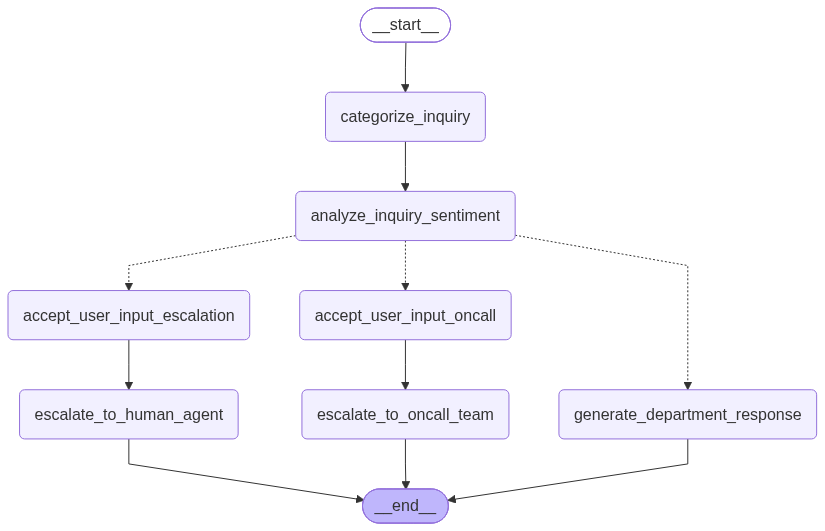

In [36]:
from IPython.display import display, Image, Markdown

display(Image(compiled_support_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

## Helper Function to Run the Agent

This function takes a customer query and runs it through our compiled agent, returning the final results (category, sentiment, and generated response).

In [37]:
def call_support_agent(agent, prompt, user_session_id, verbose=False):
    events = agent.stream(
        {"customer_query": prompt}, # initial state of the agent
        {"configurable": {"thread_id": user_session_id}},
        stream_mode="values",
    )

    print('Running Agent. Please wait...')
    for event in events:
        if verbose:
                print(event)


    print('\nFinal Response:')
    display(Markdown(event['final_response']))

## Testing the Customer Support Router RAG Agent

Let's test the workflow with some sample queries to verify categorization, sentiment analysis, and response generation.

In [39]:
uid = 's1'
query = "I am unable to breathe properly, need help"
call_support_agent(agent=compiled_support_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
{'customer_query': 'I am unable to breathe properly, need help'}
{'customer_query': 'I am unable to breathe properly, need help', 'query_category': 'Appointments'}
{'customer_query': 'I am unable to breathe properly, need help', 'query_category': 'Appointments', 'query_sentiment': 'Distress'}


.............................{'customer_query': 'I am unable to breathe properly, need help', 'query_category': 'Appointments', 'query_sentiment': 'Distress', 'oncall_cust_info': {'name': 'pg', 'number': '123'}}
{'customer_query': 'I am unable to breathe properly, need help', 'query_category': 'Appointments', 'query_sentiment': 'Distress', 'oncall_cust_info': {'name': 'pg', 'number': '123'}, 'final_response': "Don't worry pg!, someone from our on-call expert doctors will be reaching out to your shortly at 123 for assistance immediately!"}

Final Response:


Don't worry pg!, someone from our on-call expert doctors will be reaching out to your shortly at 123 for assistance immediately!

In [40]:
query = "how do I get my invoice?"
call_support_agent(agent=compiled_support_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=False)

Running Agent. Please wait...

Final Response:


Subject: How to Access Your Invoice

Dear [Customer's Name],

Thank you for reaching out regarding your invoice. You can easily obtain your invoice by following these steps:

1. Log into your patient portal using your credentials.
2. Once logged in, navigate to the 'Billing' section.
3. To view your detailed invoice, click on the appropriate option that corresponds to your services.

If you would like to view your overall healthcare billing statement, you can do so by selecting 'Billing Statements' within the same section of the patient portal.

If you encounter any issues or have further questions, please feel free to reach out.

Best regards,  
[Your Name]  
[Your Position]  
[Your Contact Information]  